In [2]:
import my_data_manager as mdm

cat = mdm.load_cat("Data/galaxies_subhalos_zphot.cat")
halos = mdm.separate_halos(cat)
clusters, groups = mdm.separate_clusters(halos)

/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/my_data_manager.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(cat, delim_whitespace=True, header=None)
/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/my_data_manager.py:56: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cat, delim_whitespace=True, header=None)


In [3]:
from astropy.stats import biweight_location
import numpy as np

z_all = np.array([
    biweight_location(df["z_app"].astype(float))
    for df in clusters
])

cut_idx = 678

z_good = z_all[:cut_idx]
z_bad = z_all[cut_idx:]

print("=== GOOD HALOS ===")
print(f"Mean z: {np.mean(z_good):.3f} ± {np.std(z_good):.3f}")
print(f"Median z: {np.median(z_good):.3f}")
print(f"Min/Max z: {np.min(z_good):.3f} / {np.max(z_good):.3f}")

print("\n=== BAD HALOS ===")
print(f"Mean z: {np.mean(z_bad):.3f} ± {np.std(z_bad):.3f}")
print(f"Median z: {np.median(z_bad):.3f}")
print(f"Min/Max z: {np.min(z_bad):.3f} / {np.max(z_bad):.3f}")

=== GOOD HALOS ===
Mean z: 0.389 ± 0.117
Median z: 0.401
Min/Max z: 0.102 / 0.577

=== BAD HALOS ===
Mean z: 0.376 ± 0.182
Median z: 0.474
Min/Max z: 0.046 / 0.549


In [3]:
clusters = clusters[:678]

In [3]:
print(len(clusters))

678


In [4]:
print(clusters[0].columns)

Index(['galaxyId', 'haloId', 'pos_x', 'pos_y', 'pos_z', 'vel_x', 'vel_y',
       'vel_z', 'redshift', 'snapshot', 'sfr', 'm_star', 'm_coldgas',
       'Z_coldgas', 'R_coldgas', 'sfh_bin', 'sfh_nbin', 'RA', 'DEC', 'z_geo',
       'd_comoving', 'z_app', 'mag_u', 'mag_g', 'mag_r', 'mag_i', 'mag_z',
       'z_phot', 'firstHaloInFOFGroupId', 'log(m_200)'],
      dtype='object', name=0)


In [4]:
def retag_noise(cluster_list):
    
    new_cluster_list = []
    for df in cluster_list:
        counts = df.groupby("haloId")["haloId"].transform("count")
        df = df.copy()
        df.loc[counts <= 3, "haloId"] = -1
        new_cluster_list.append(df.reset_index(drop=True))
    return new_cluster_list

In [51]:
import astro_utils as au
from astropy.stats import biweight_location, biweight_scale
import pandas as pd

clusters_mpc = []

for cluster in clusters:
    cluster = cluster.copy()

    cluster["RA"] = pd.to_numeric(cluster["RA"], errors="coerce")
    cluster["DEC"] = pd.to_numeric(cluster["DEC"], errors="coerce")
    cluster["z_app"] = pd.to_numeric(cluster["z_app"], errors="coerce")

    ra_center = biweight_location(cluster["RA"].values.astype(float))
    dec_center = biweight_location(cluster["DEC"].values.astype(float))
    z_center = biweight_location(cluster["z_app"].values.astype(float))

    x, y, z = au.gal_3D_Mpc_coords(
        ra=cluster["RA"].values,
        dec=cluster["DEC"].values,
        redshift_gal=cluster["z_app"].values,
        x_center=ra_center,
        y_center=dec_center,
        z_center=z_center
    )

    cluster["X_Mpc"] = x
    cluster["Y_Mpc"] = y
    cluster["Z_Mpc"] = z

    clusters_mpc.append(cluster)

In [5]:
import pandas as pd

clean_clusters = [df[df.groupby("haloId")["haloId"].transform("count") > 3].reset_index(drop=True) for df in clusters]

N = 21

splus_clusters = [df[pd.to_numeric(df['mag_r'], errors = 'coerce') >= N].copy() for df in clusters]

nonoise_clusters = retag_noise(clusters)
nonoise_splus_clusters = retag_noise(splus_clusters)

cluster_samples = {
    "Raw": clusters,
    "Clean": clean_clusters,
    "SPLUS": splus_clusters
}

In [43]:
import cluster_utils as cu

clean_mpc_clusters = [df[df.groupby("haloId")["haloId"].transform("count") > 3].reset_index(drop=True) for df in clusters_mpc]

N = 21

splus_mpc_clusters = [df[pd.to_numeric(df['mag_r'], errors = 'coerce') >= N].copy() for df in clusters_mpc]

clusters_mpc = cu.retag_noise(clusters_mpc)
splus_mpc_clusters = cu.retag_noise(splus_mpc_clusters)

cluster_mpc_samples = {
    "Raw": clusters_mpc,
    "Clean": clean_mpc_clusters,
    "SPLUS": splus_mpc_clusters
}

In [16]:
from astropy.stats import biweight_location
import numpy as np
import pandas as pd
import astro_utils as au

invalid_halo_ids = []

redshifts = []
masses = []
r_200 = []
extent_max_r200 = []
extent_p90_r200 = []
extent_max_mpc = []
extent_p90_mpc = []
halo_ids = []

for df in clusters:
    avg_z_app = biweight_location(df["z_app"].astype(float))
    log_m200 = float(df["log(m_200)"].iloc[0])
    halo_r200 = au.get_r_200(log_m200, avg_z_app, H0=67.3, Om0=0.3)

    fof_id = str(df["firstHaloInFOFGroupId"].iloc[0])

    # Save invalid halo IDs
    if halo_r200 < 1:
        invalid_halo_ids.append(fof_id)

    center_x = biweight_location(df["pos_x"].astype(float))
    center_y = biweight_location(df["pos_y"].astype(float))
    center_z = biweight_location(df["pos_z"].astype(float))

    dx = df["pos_x"].astype(float).values - center_x
    dy = df["pos_y"].astype(float).values - center_y
    dz = df["pos_z"].astype(float).values - center_z

    radii_3d = np.sqrt(dx**2 + dy**2 + dz**2)

    max_extent = np.max(radii_3d)
    p90_extent = np.percentile(radii_3d, 90)

    halo_ids.append(fof_id)
    redshifts.append(avg_z_app)
    masses.append(log_m200)
    r_200.append(halo_r200)

    extent_max_mpc.append(max_extent)
    extent_p90_mpc.append(p90_extent)
    extent_max_r200.append(max_extent / halo_r200)
    extent_p90_r200.append(p90_extent / halo_r200)

results = pd.DataFrame({
    "haloId": halo_ids,
    "z_app": redshifts,
    "log_m200": masses,
    "r200": r_200,
    "extent_max_mpc": extent_max_mpc,
    "extent_p90_mpc": extent_p90_mpc,
    "extent_max_r200": extent_max_r200,
    "extent_p90_r200": extent_p90_r200,
})

invalid_halo_ids = set(invalid_halo_ids)

print(results)

               haloId     z_app   log_m200      r200  extent_max_mpc  \
0    33000032000016.0  0.441942  14.248211  1.016856        2.720390   
1    34000013000011.0  0.184798  14.716545  1.603586        2.807912   
2    34000013041903.0  0.186027  14.310159  1.173390        2.542774   
3    34010484000010.0  0.180112  14.638484  1.512814        3.239572   
4    35000043000018.0  0.516044  14.514191  1.211381        2.950831   
..                ...       ...        ...       ...             ...   
726   6000038000017.0  0.494998  14.550436  1.255938        2.790459   
727   6000306003023.0  0.486075  14.459964  1.175807        1.629100   
728   6020170012480.0  0.489514  14.260069  1.007202        5.320536   
729   8012933000387.0  0.510842  14.353246  1.072814        2.915960   
730   8012934000804.0  0.508674  14.779971  1.489834        2.258352   

     extent_p90_mpc  extent_max_r200  extent_p90_r200  
0          1.725045         2.675296         1.696450  
1          2.068843    

In [18]:
import numpy as np

# =========================
# Redshift
# =========================
avg_z_app = np.mean(redshifts)
med_z_app = np.median(redshifts)
std_z_app = np.std(redshifts)

print(f"Average z_app: {avg_z_app:.3f} ± {std_z_app:.3f}")
print(f"Median z_app: {med_z_app:.3f} ± {std_z_app:.3f}")

print(f"Max z_app: {np.max(redshifts):.3f}")
print(f"Min z_app: {np.min(redshifts):.3f}")


# =========================
# Mass
# =========================
stellar_masses = [10**m for m in masses]

avg_m200 = np.log10(np.mean(stellar_masses))
med_m200 = np.log10(np.median(stellar_masses))
std_m200 = np.log10(np.std(stellar_masses))  # keeping your convention

print(f"Average log(m_200): {avg_m200:.3f} ± {std_m200:.3f}")
print(f"Median log(m_200): {med_m200:.3f} ± {std_m200:.3f}")

print(f"Max log(m_200): {np.max(masses):.3f}")
print(f"Min log(m_200): {np.min(masses):.3f}")


# =========================
# R200
# =========================
avg_r_200 = np.mean(r_200)
med_r_200 = np.median(r_200)
std_r_200 = np.std(r_200)

print(f"Average r_200: {avg_r_200:.3f} ± {std_r_200:.3f}")
print(f"Median r_200: {med_r_200:.3f} ± {std_r_200:.3f}")

print(f"Max r_200: {np.max(r_200):.3f}")
print(f"Min r_200: {np.min(r_200):.3f}")


# =========================
# EXTENT IN R200 UNITS
# =========================
avg_ext_max_r200 = np.mean(extent_max_r200)
med_ext_max_r200 = np.median(extent_max_r200)
std_ext_max_r200 = np.std(extent_max_r200)

print(f"Average extent_max (R200): {avg_ext_max_r200:.3f} ± {std_ext_max_r200:.3f}")
print(f"Median extent_max (R200): {med_ext_max_r200:.3f} ± {std_ext_max_r200:.3f}")

print(f"Max extent_max (R200): {np.max(extent_max_r200):.3f}")
print(f"Min extent_max (R200): {np.min(extent_max_r200):.3f}")


# =========================
# ROBUST EXTENT (P90)
# =========================
avg_ext_p90_r200 = np.mean(extent_p90_r200)
med_ext_p90_r200 = np.median(extent_p90_r200)
std_ext_p90_r200 = np.std(extent_p90_r200)

print(f"Average extent_p90 (R200): {avg_ext_p90_r200:.3f} ± {std_ext_p90_r200:.3f}")
print(f"Median extent_p90 (R200): {med_ext_p90_r200:.3f} ± {std_ext_p90_r200:.3f}")

print(f"Max extent_p90 (R200): {np.max(extent_p90_r200):.3f}")
print(f"Min extent_p90 (R200): {np.min(extent_p90_r200):.3f}")

Average z_app: 0.388 ± 0.123
Median z_app: 0.405 ± 0.123
Max z_app: 0.577
Min z_app: 0.046
Average log(m_200): 14.512 ± 14.358
Median log(m_200): 14.421 ± 14.358
Max log(m_200): 15.531
Min log(m_200): 14.116
Average r_200: 1.234 ± 0.213
Median r_200: 1.180 ± 0.213
Max r_200: 2.887
Min r_200: 1.001
Average extent_max (R200): 2.085 ± 0.606
Median extent_max (R200): 1.948 ± 0.606
Max extent_max (R200): 5.490
Min extent_max (R200): 0.993
Average extent_p90 (R200): 1.393 ± 0.425
Median extent_p90 (R200): 1.272 ± 0.425
Max extent_p90 (R200): 4.032
Min extent_p90 (R200): 0.669


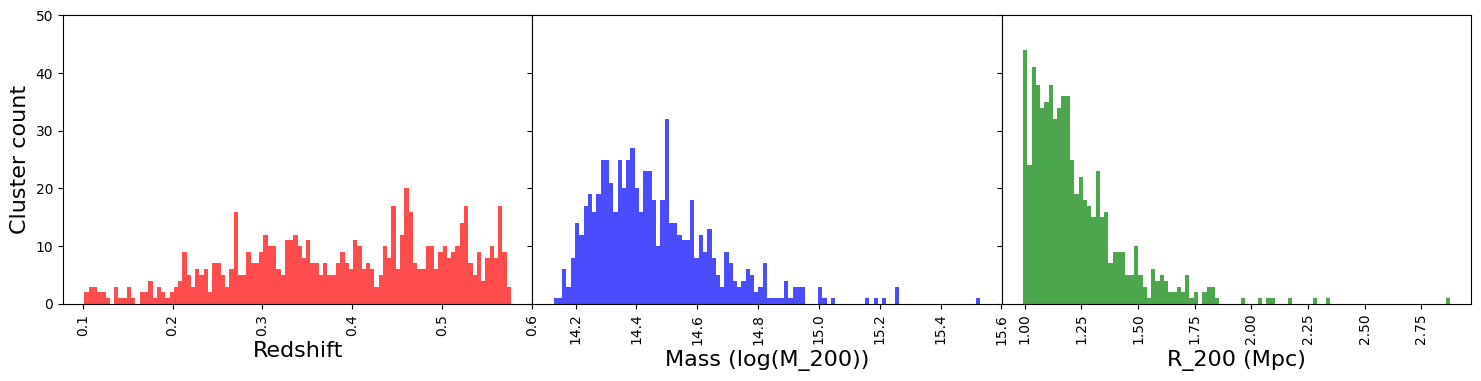

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, wspace=0)  # wspace=0 removes horizontal spacing

# First histogram
ax1 = fig.add_subplot(gs[0])
ax1.hist(redshifts, bins=100, color='red', alpha=0.7)
ax1.set_xlabel('Redshift', fontsize=16)
ax1.set_ylim(0, 50)
ax1.set_ylabel('Cluster count', fontsize=16)


# Second histogram, share y-axis with ax1
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax2.hist(masses, bins=100, color='blue', alpha=0.7)
ax2.set_xlabel('Mass (log(M_200))', fontsize=16)
plt.setp(ax2.get_yticklabels(), visible=False)  # Hide duplicate y-ticks

# Third histogram, share y-axis again
ax3 = fig.add_subplot(gs[2], sharey=ax1)
ax3.hist(r_200, bins=100, color='green', alpha=0.7)
ax3.set_xlabel('R_200 (Mpc)', fontsize=16)
plt.setp(ax3.get_yticklabels(), visible=False)

for ax in [ax1, ax2, ax3]:
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout(pad=5)
plt.show()



In [10]:
min_len = min(len(df) for df in clean_clusters)
print(f"Min length of clusters: {min_len}")
max_len = max(len(df) for df in clean_clusters)
print(f"Max length of clusters: {max_len}")

Min length of clusters: 51
Max length of clusters: 1169


In [11]:
#sorted_dfs = [df for _, df in sorted(zip(redshifts, clusters), key=lambda x: x[0])]

substructures = []

for df in clusters:
    
    group_counts = df['haloId'].value_counts() 
    small = 0
    medium = 0
    big =0

    for count in group_counts.values:
        if count < 3:
            small += 1
            continue
        if count < 10:
            medium += 1
            continue
        big += 1

    substructures.append((small, medium, big))





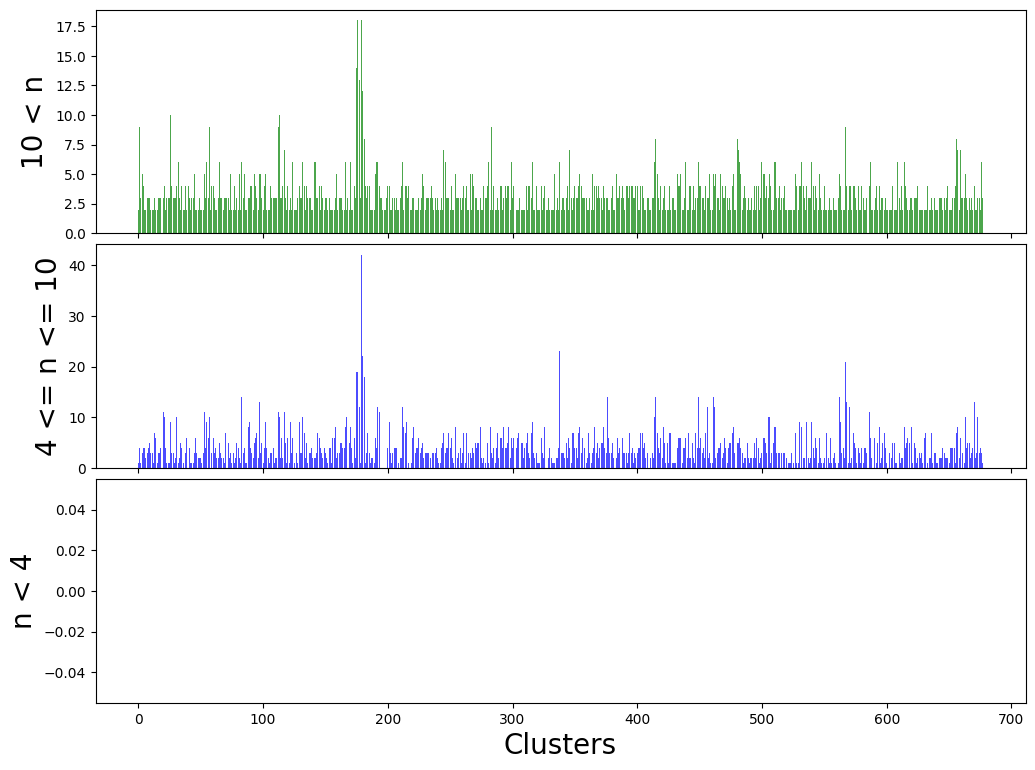

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

fig = plt.figure(figsize=(12, 9))
gs = gridspec.GridSpec(3, 1, hspace=0.05)  # wspace=0 removes horizontal spacing

small_subs = [s[0] for s in substructures]
medium_subs = [s[1] for s in substructures]
big_subs = [s[2] for s in substructures]
cluster_ids = list(range(len(substructures)))

ax1 = fig.add_subplot(gs[2])
ax1.bar(cluster_ids, small_subs, color='red', alpha=0.7)
ax1.set_ylabel('n < 4', fontsize=20)
ax1.set_xlabel('Clusters', fontsize=20)
plt.setp(ax1.get_yticklabels(), visible=True)
plt.setp(ax1.get_xticklabels(), visible=True)

ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.bar(cluster_ids, medium_subs, color='blue', alpha=0.7)
ax2.set_ylabel('4 <= n <= 10', fontsize=20)
#plt.setp(ax2.get_yticklabels(), visible=True)
plt.setp(ax2.get_xticklabels(), visible=False)

ax3 = fig.add_subplot(gs[0], sharex=ax1)
ax3.bar(cluster_ids, big_subs, color='green', alpha=0.7)
ax3.set_ylabel('10 < n', fontsize=20)
plt.setp(ax3.get_xticklabels(), visible=False)

#plt.tight_layout(pad=3)
plt.show()


0.06578947368421052


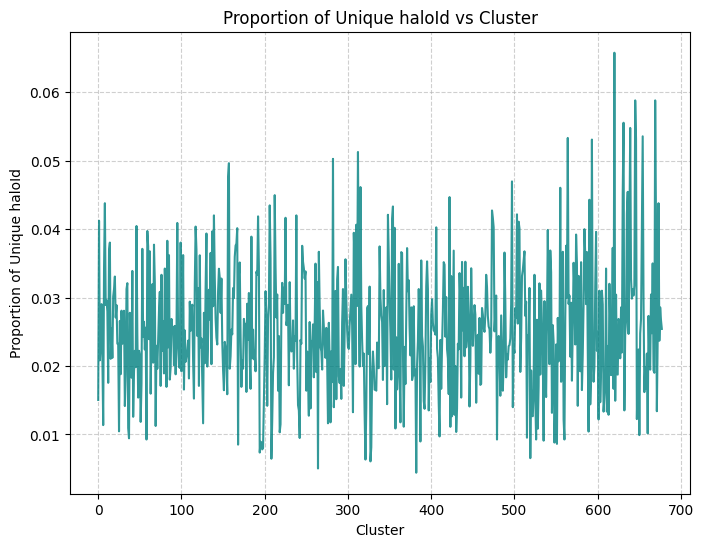

In [ ]:

import matplotlib.pyplot as plt



# Calculate the proportion for each DataFrame
proportions = [
    a['haloId'].nunique() / len(b) if len(b) > 0 else 0
    for a, b in zip(clean_clusters, nonoise_splus_clusters)
]
print(max(proportions))

# Cluster IDs for x-axis
cluster_ids = range(len(nonoise_clusters))

# Plot as a line graph
plt.figure(figsize=(8, 6))
plt.plot(cluster_ids, proportions, color='teal', alpha=0.8)
plt.xlabel('Cluster')
plt.ylabel('Proportion of Unique haloId')
plt.title('Proportion of Unique haloId vs Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [14]:
import glob
import os
import pandas as pd

def load_results(sample_type: str):

    folder = f"results_{sample_type}_samples"
    results_df = {}
    
    files = glob.glob(os.path.join(folder, "*.xlsx"))


    for f in files:
        
        xls = pd.ExcelFile(f)
        sheet_names = xls.sheet_names  # skip the first sheet
        
        key = os.path.splitext(os.path.basename(f))[0]

        df_time = pd.read_excel(xls, sheet_name=sheet_names[0])
        df_time = df_time.iloc[:, 0] 

        executions = []
        for name in sheet_names[1:]:
            df = pd.read_excel(xls, sheet_name=name)
            df.columns = df.columns.map(str)
            executions.append(df)
        
        results_df[key] = {"time": df_time, "executions": executions}

    return results_df

In [6]:
import pandas as pd
import numpy as np

# Baseline: RAW
raw_list = nonoise_clusters
clean_list = clean_clusters
splus_list = nonoise_splus_clusters

# Lists to store the survival ratios
clean_ratios = []
splus_ratios = []

# Iterate through the clusters (assuming the lists are ordered the same)
for i in range(len(raw_list)):
    n_raw = len(raw_list[i])
    
    # Avoid division by zero if a raw cluster is somehow empty
    if n_raw == 0:
        continue
        
    # Survival in Clean (Noise filtered)
    n_clean = len(clean_list[i])
    clean_ratios.append(n_clean / n_raw)
    
    # Survival in SPLUS (Magnitude cut)
    n_splus = len(splus_list[i])
    splus_ratios.append(n_splus / n_raw)

# Convert to percentages for the final report
clean_ratios = np.array(clean_ratios) * 100
splus_ratios = np.array(splus_ratios) * 100

# Create the summary table
analysis_data = [
    {
        "Regimen": "CLEAN",
        "Avg Survival (%)": np.mean(clean_ratios),
        "Std Dev (%)": np.std(clean_ratios),
        "Min Survival (%)": np.min(clean_ratios),
        "Max Survival (%)": np.max(clean_ratios)
    },
    {
        "Regimen": "SPLUS",
        "Avg Survival (%)": np.mean(splus_ratios),
        "Std Dev (%)": np.std(splus_ratios),
        "Min Survival (%)": np.min(splus_ratios),
        "Max Survival (%)": np.max(splus_ratios)
    }
]

df_report = pd.DataFrame(analysis_data)

print("--- Per-Cluster Data Survival Analysis ---")
print(df_report.round(2).to_string(index=False))

--- Per-Cluster Data Survival Analysis ---
Regimen  Avg Survival (%)  Std Dev (%)  Min Survival (%)  Max Survival (%)
  CLEAN             49.49         5.81             34.85             74.77
  SPLUS             88.65         9.71             42.20             99.55


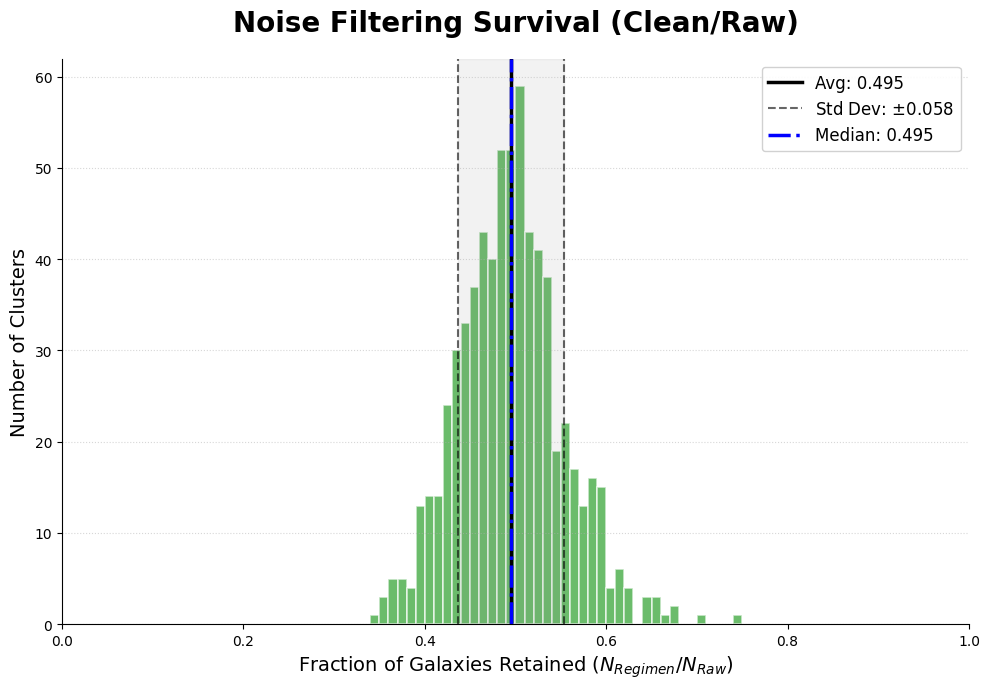

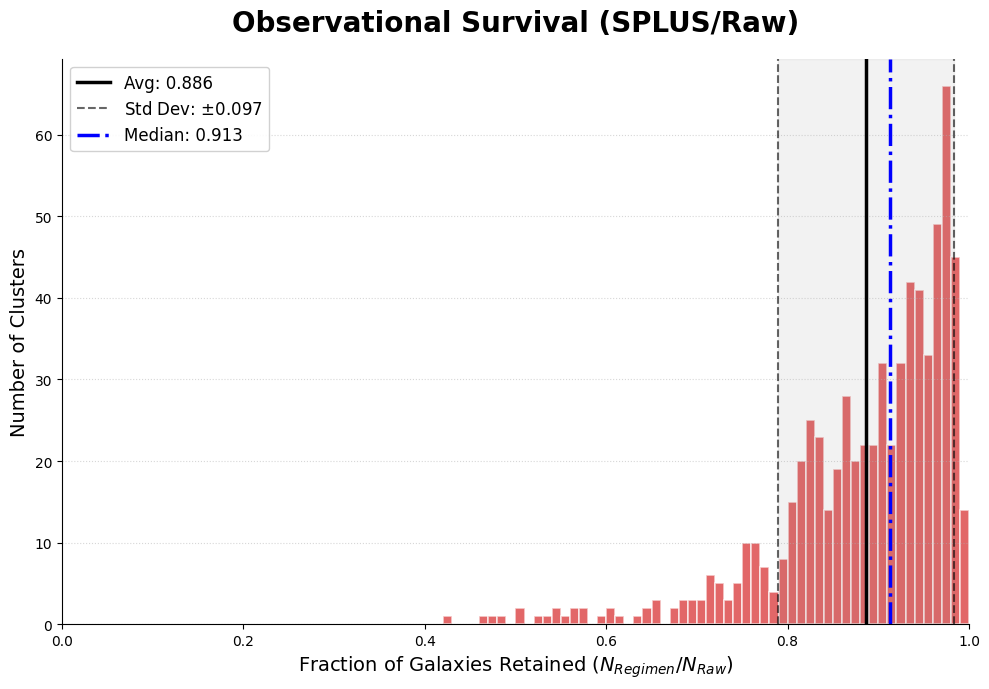

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


clean_fractions = []
splus_fractions = []

for i in range(len(raw_list)):
    n_raw = len(raw_list[i])
    if n_raw == 0: continue
    
    clean_fractions.append(len(clean_list[i]) / n_raw)
    splus_fractions.append(len(splus_list[i]) / n_raw)

# Convert to numpy for stats
clean_fractions = np.array(clean_fractions)
splus_fractions = np.array(splus_fractions)

# 2. Define Plotting Helper
def save_survival_histogram(data, title, filename, color):
    avg = np.mean(data)
    std = np.std(data)
    median = np.median(data)
    
    plt.figure(figsize=(10, 7))
    
    # Histogram
    counts, bins, patches = plt.hist(data, bins=100, range=(0, 1), 
                                     color=color, alpha=0.7, 
                                     edgecolor='white', linewidth=1.2)
    
    # Marking Statistics
    plt.axvline(avg, color='black', linestyle='-', linewidth=2.5, 
                label=f'Avg: {avg:.3f}')
    
    # Marking Std Dev with dashed lines
    plt.axvline(avg - std, color='black', linestyle='--', linewidth=1.5, alpha=0.6,
                label=f'Std Dev: $\pm${std:.3f}')
    plt.axvline(avg + std, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Shading the Std Dev region
    plt.axvspan(max(0, avg - std), min(1, avg + std), color='gray', alpha=0.1)

    plt.axvline(median, color='blue', linestyle='-.', linewidth=2.5, label=f'Median: {median:.3f}')

    # Aesthetics
    plt.title(title, fontsize=20, fontweight='bold', pad=20)
    plt.xlabel("Fraction of Galaxies Retained ($N_{Regimen} / N_{Raw}$)", fontsize=14)
    plt.ylabel("Number of Clusters", fontsize=14)
    plt.xlim(0, 1)
    
    # Ensure Y-axis uses integers for counts
    plt.gca().yaxis.get_major_locator().set_params(integer=True)
    
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend(fontsize=12, frameon=True, facecolor='white', framealpha=0.9)
    
    # Clean spines
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)
        
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

# 3. Generate Separated Plots
save_survival_histogram(clean_fractions, "Noise Filtering Survival (Clean/Raw)", 
                         "histogram_clean_survival.png", "#2ca02c")

save_survival_histogram(splus_fractions, "Observational Survival (SPLUS/Raw)", 
                         "histogram_splus_survival.png", "#d62728")

/tmp/ipykernel_1333/2670473754.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette_name, len(unique_halos))
/tmp/ipykernel_1333/2670473754.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette_name, len(unique_halos))
/tmp/ipykernel_1333/2670473754.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette_name, len(unique_halos))


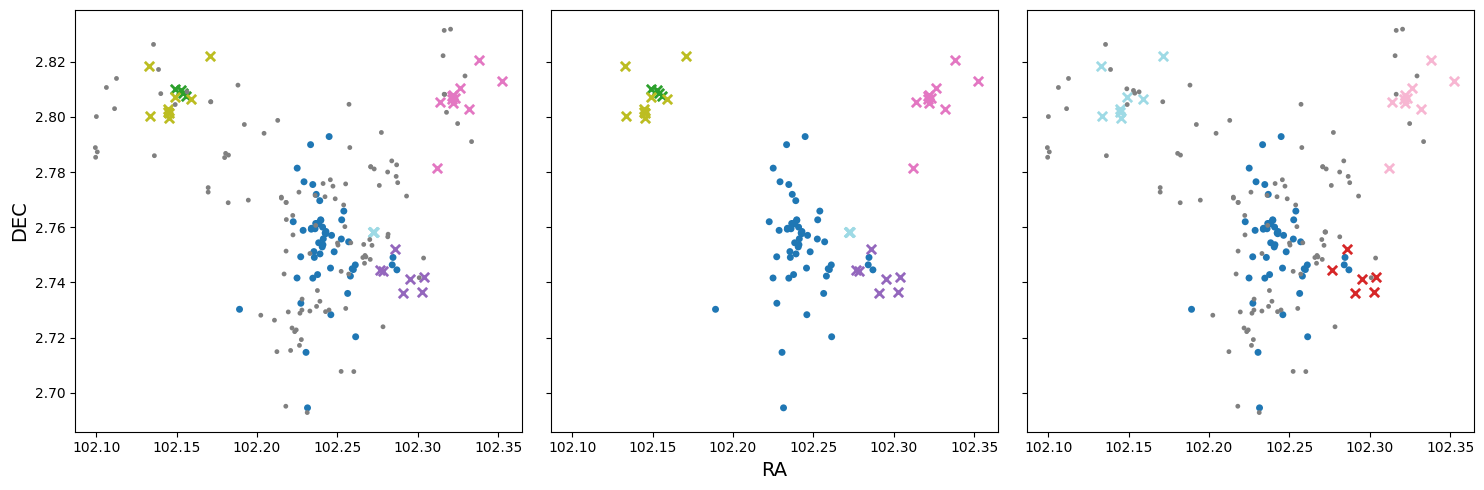

Random cluster index: 544
Halo: 343983    374000120000015.0
343984    374000120000015.0
343985    374000120000015.0
343986    374000120000015.0
343987    374000120000015.0
                ...        
344330    374000120037725.0
344331    374000120037775.0
344332    374000120037813.0
344333    374000120037861.0
344334    374000120037901.0
Name: haloId, Length: 199, dtype: object


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# =========================================================
# CONFIGURATION
# =========================================================

palette_name = "tab20"

# gray/noise points
gray_alpha = 1
gray_size  = 12

# main cluster (FIRST GROUP)
main_alpha = 1
main_size  = 25

# secondary subhalos
secondary_alpha = 1
secondary_size  = 45

# =========================================================
# SCATTER FUNCTION
# =========================================================

def scatter_by_subhalo(
    ax,
    df,
    xcol="RA",
    ycol="DEC",
    halo_col="haloId",
    palette_name="tab20",
    gray_alpha=0.25,
    gray_size=8,
    main_alpha=0.9,
    main_size=25,
    secondary_alpha=0.9,
    secondary_size=35
):

    if len(df) == 0:
        return

    halos = df[halo_col].astype(str)

    noise_labels = ["-1", "-1.0"]

    # all real halos
    unique_halos = sorted(
        [h for h in halos.unique() if h not in noise_labels]
    )

    if len(unique_halos) == 0:
        return

    # -----------------------------------------------------
    # MAIN CLUSTER = FIRST GROUP
    # -----------------------------------------------------
    main_halo = unique_halos[0]

    # colormap
    cmap = cm.get_cmap(palette_name, len(unique_halos))

    # -----------------------------------------------------
    # plot halos
    # -----------------------------------------------------
    for idx, halo in enumerate(unique_halos):

        mask = halos == halo

        # MAIN CLUSTER -> DOTS
        if halo == main_halo:

            ax.scatter(
                df.loc[mask, xcol],
                df.loc[mask, ycol],
                s=main_size,
                alpha=main_alpha,
                color=cmap(idx),
                marker="o",
                edgecolors="none"
            )

        # SECONDARY STRUCTURES -> X
        else:

            ax.scatter(
                df.loc[mask, xcol],
                df.loc[mask, ycol],
                s=secondary_size,
                alpha=secondary_alpha,
                color=cmap(idx),
                marker="x",
                linewidths=2
            )

    # -----------------------------------------------------
    # NOISE / FIELD GALAXIES
    # -----------------------------------------------------
    noise_mask = halos.isin(noise_labels)

    if noise_mask.sum() > 0:

        ax.scatter(
            df.loc[noise_mask, xcol],
            df.loc[noise_mask, ycol],
            s=gray_size,
            alpha=gray_alpha,
            color="gray",
            marker="o",
            edgecolors="none"
        )


# =========================================================
# PICK RANDOM CLUSTER
# =========================================================

rng = np.random.default_rng()

valid = [
    i for i in range(min(len(raw_list), len(clean_list), len(splus_list)))
    if (len(raw_list[i]) + len(clean_list[i]) + len(splus_list[i])) > 0
]

i = int(rng.choice(valid))
#i = 131

raw_df   = raw_list[i]
clean_df = clean_list[i]
splus_df = splus_list[i]

# =========================================================
# PLOT
# =========================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

scatter_by_subhalo(
    axes[0],
    raw_df,
    palette_name=palette_name,
    gray_alpha=gray_alpha,
    gray_size=gray_size,
    main_alpha=main_alpha,
    main_size=main_size,
    secondary_alpha=secondary_alpha,
    secondary_size=secondary_size
)

scatter_by_subhalo(
    axes[1],
    clean_df,
    palette_name=palette_name,
    gray_alpha=gray_alpha,
    gray_size=gray_size,
    main_alpha=main_alpha,
    main_size=main_size,
    secondary_alpha=secondary_alpha,
    secondary_size=secondary_size
)

scatter_by_subhalo(
    axes[2],
    splus_df,
    palette_name=palette_name,
    gray_alpha=gray_alpha,
    gray_size=gray_size,
    main_alpha=main_alpha,
    main_size=main_size,
    secondary_alpha=secondary_alpha,
    secondary_size=secondary_size
)

# remove labels
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

axes[0].set_ylabel("DEC", fontsize=14)
axes[1].set_xlabel("RA", fontsize=14)

# =========================================================
# CONSISTENT LIMITS
# =========================================================

all_df = [d for d in [raw_df, clean_df, splus_df] if len(d) > 0]

xmin = min(d["RA"].min() for d in all_df)
xmax = max(d["RA"].max() for d in all_df)

ymin = min(d["DEC"].min() for d in all_df)
ymax = max(d["DEC"].max() for d in all_df)

margin = 0.05

dx = xmax - xmin
dy = ymax - ymin

xmin -= dx * margin
xmax += dx * margin

ymin -= dy * margin
ymax += dy * margin

for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

# =========================================================
# INFO
# =========================================================

halo_id = clusters[i]["haloId"]

print(f"Random cluster index: {i}")
print(f"Halo: {halo_id}")

In [52]:
import numpy as np
import pandas as pd
from astropy.stats import biweight_location, biweight_scale

keys = ["Raw", "Clean", "SPLUS"]

subhalo_sizes = {}

for key in keys:
# Choose sample
    sample = cluster_mpc_samples[key]   # or "Clean", "SPLUS"

    rows = []

    for cluster in sample:
        cluster = cluster.copy()

        cluster["haloId"] = cluster["haloId"].astype(str)
        cluster["firstHaloInFOFGroupId"] = cluster["firstHaloInFOFGroupId"].astype(str)
        cluster["log(m_200)"] = pd.to_numeric(cluster["log(m_200)"], errors="coerce")

        # Remove noise and central FoF halo
        sub_df = cluster[
            (cluster["haloId"] != "-1") &
            (cluster["haloId"] != "-1.0") &
            (cluster["haloId"] != cluster["firstHaloInFOFGroupId"])
        ].copy()

        for halo_id, group in sub_df.groupby("haloId"):
            if len(group) < 2:
                continue

            coords = group[["X_Mpc", "Y_Mpc", "Z_Mpc"]].to_numpy(dtype=float)

            center = biweight_location(coords, axis=0)
            scale = biweight_scale(coords, axis=0)

            # Single scalar size from 3D biweight scale
            scale_3d = np.linalg.norm(scale)
     
            # Optional projected XY scale
            scale_xy = np.linalg.norm(scale[:2])

            log_m200 = float(group["log(m_200)"].unique()[0])

            z_subhalo = float(biweight_location(pd.to_numeric(group["z_app"], errors="coerce")))
            r200 = au.get_r_200(log_m200, center[2])

            rows.append({
                "FoFHaloID": group["firstHaloInFOFGroupId"].iloc[0],
                "haloId": halo_id,
                "N_gal": len(group),
                "X_center": center[0],
                "Y_center": center[1],
                "Z_center": center[2],
                "scale_X": scale[0],
                "scale_Y": scale[1],
                "scale_Z": scale[2],
                "scale_3D_Mpc": scale_3d,
                "scale_XY_Mpc": scale_xy,
                "R200_Mpc": r200
            })

    df = pd.DataFrame(rows)
    subhalo_sizes[key] = df

/home/gasep/Projects/GitHub/ClusteringComparison/.venv/lib/python3.11/site-packages/astropy/cosmology/_src/flrw/lambdacdm.py:765: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(zp1**3 * (Or * zp1 + self.Om0) + self.Ode0)
/home/gasep/Projects/GitHub/ClusteringComparison/.venv/lib/python3.11/site-packages/astropy/cosmology/_src/flrw/lambdacdm.py:765: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(zp1**3 * (Or * zp1 + self.Om0) + self.Ode0)
/home/gasep/Projects/GitHub/ClusteringComparison/.venv/lib/python3.11/site-packages/astropy/cosmology/_src/flrw/lambdacdm.py:765: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(zp1**3 * (Or * zp1 + self.Om0) + self.Ode0)
/home/gasep/Projects/GitHub/ClusteringComparison/.venv/lib/python3.11/site-packages/astropy/cosmology/_src/flrw/lambdacdm.py:765: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(zp1**3 * (Or * zp1 + self.Om0) + self.Ode0)
/home/gasep/Projects/GitHub/Clusteri

In [55]:
for key in keys:

    print(f"=================={key}==================")

    summary = subhalo_sizes[key][["scale_3D_Mpc", "scale_XY_Mpc", "R200_Mpc"]].agg(
        ["min", "max", "mean", "std"]
    )

    print(summary)
    print("\n")

==================Raw==================
      scale_3D_Mpc  scale_XY_Mpc  R200_Mpc
min       0.061732      0.000538  0.007611
max      30.508208      1.525420  2.672196
mean      4.432023      0.166159  0.207832
std       3.442222      0.174326  0.231125


==================Clean==================
      scale_3D_Mpc  scale_XY_Mpc  R200_Mpc
min       0.061732      0.000538  0.007611
max      30.508208      1.525420  2.672196
mean      4.432023      0.166159  0.207832
std       3.442222      0.174326  0.231125


==================SPLUS==================
      scale_3D_Mpc  scale_XY_Mpc  R200_Mpc
min       0.082763      0.001389  0.007611
max      29.171248      1.871635  3.658238
mean      5.055983      0.215945  0.229783
std       3.450630      0.199143  0.266965




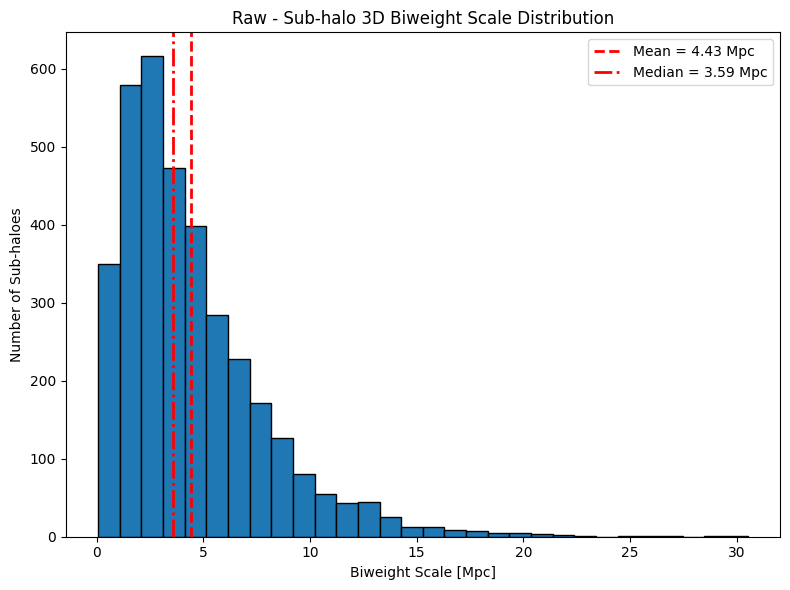

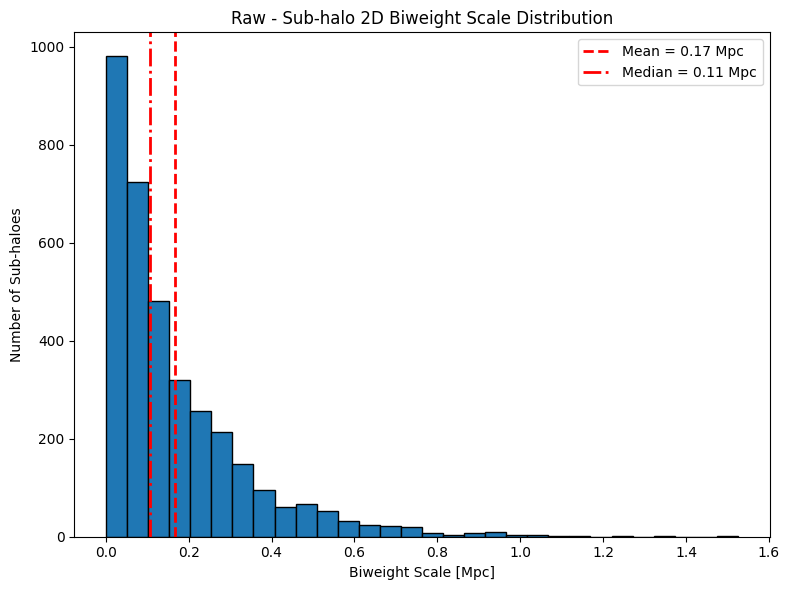

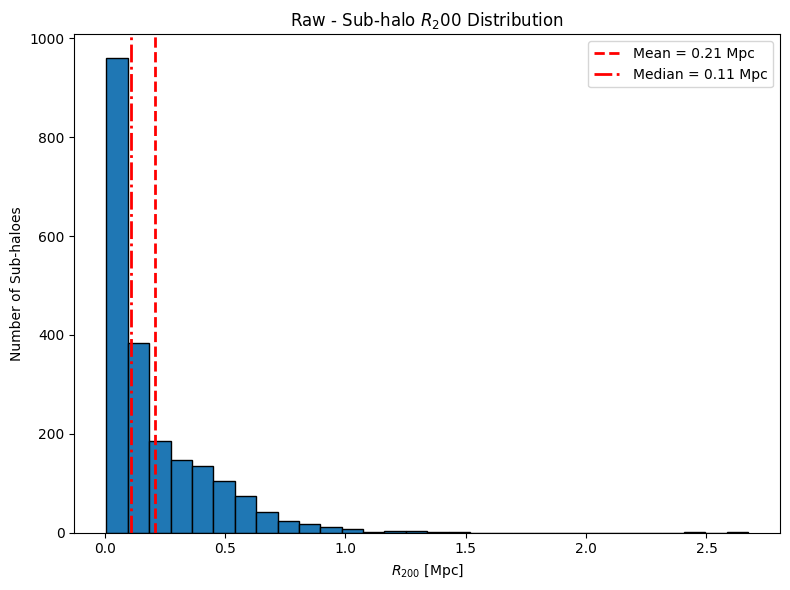

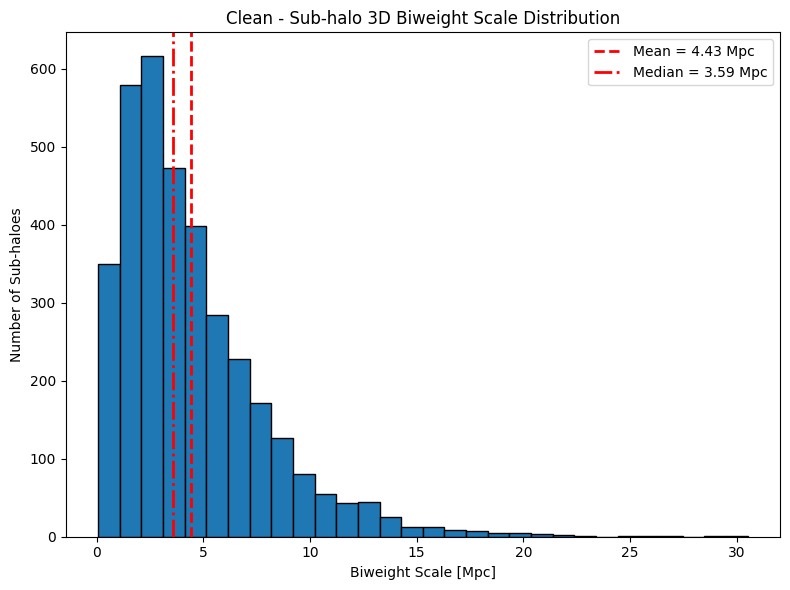

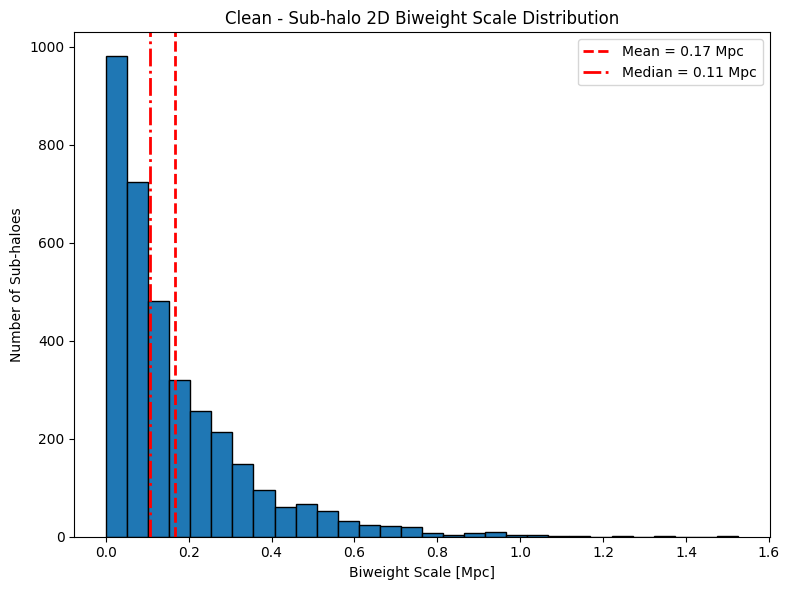

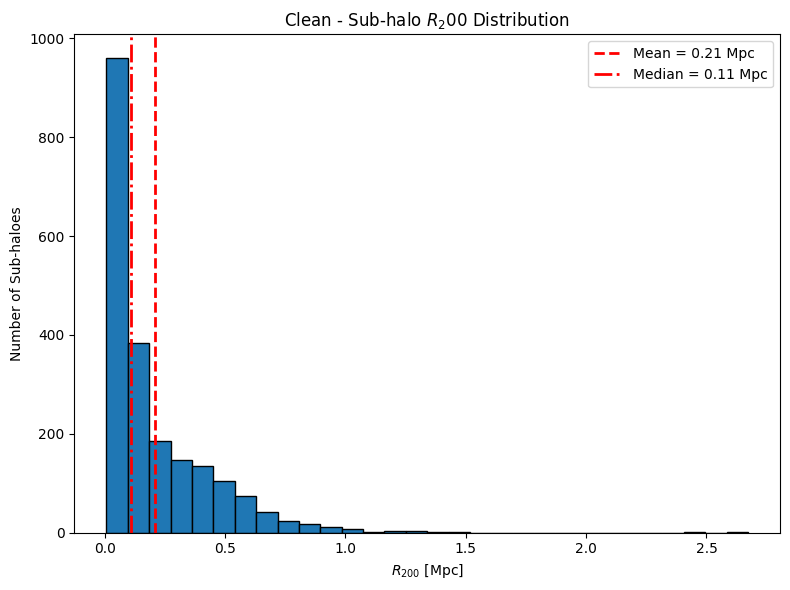

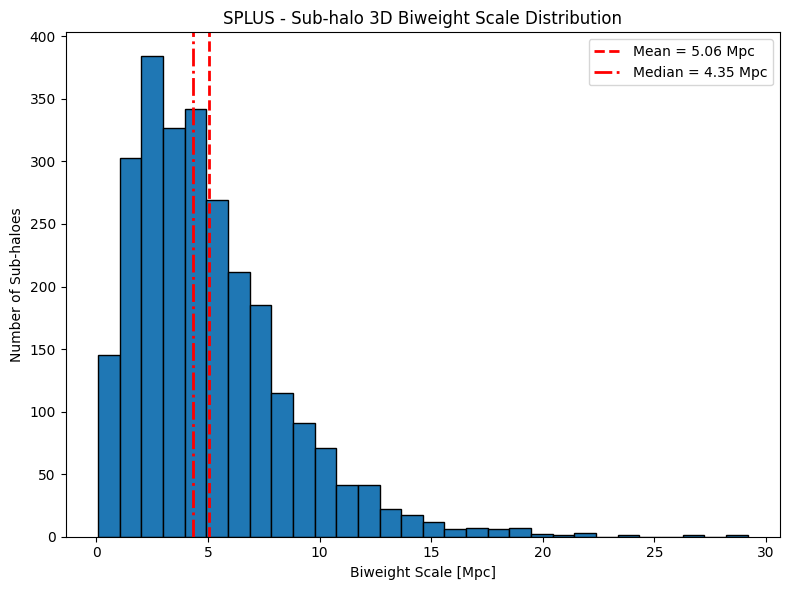

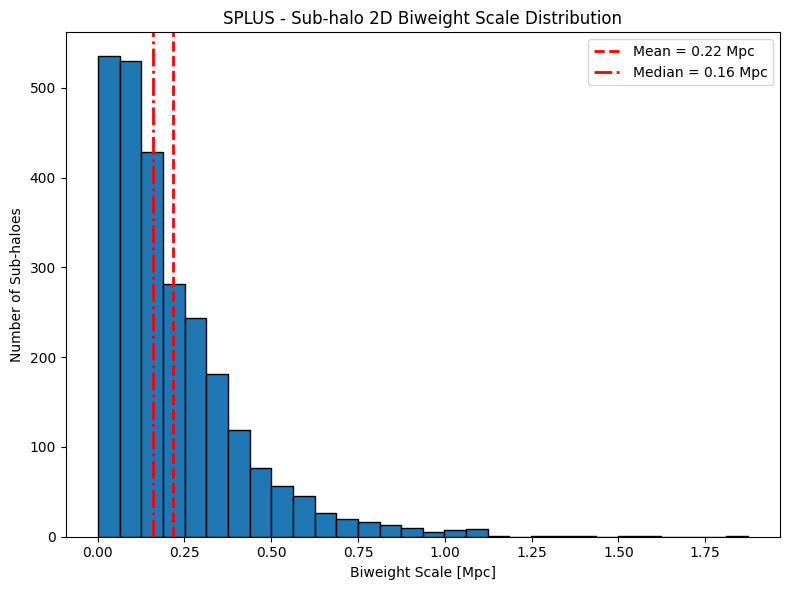

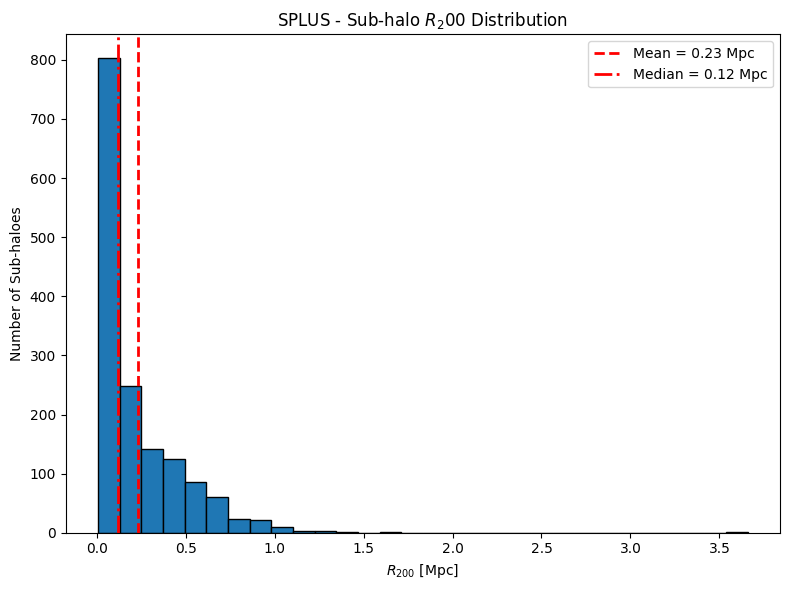

In [56]:
import matplotlib.pyplot as plt
import numpy as np

for key in keys:

    # ---------- CLEAN DATA ----------
    scale_data = subhalo_sizes[key]["scale_3D_Mpc"]
    scale_data = scale_data[np.isfinite(scale_data)]

    XY_scale_data = subhalo_sizes[key]["scale_XY_Mpc"]
    XY_scale_data = XY_scale_data[np.isfinite(XY_scale_data)]

    r200_data = subhalo_sizes[key]["R200_Mpc"]
    r200_data = r200_data[np.isfinite(r200_data)]

    # ---------- STATISTICS ----------
    scale_mean = np.mean(scale_data)
    scale_median = np.median(scale_data)
    
    XY_scale_mean = np.mean(XY_scale_data)
    XY_scale_median = np.median(XY_scale_data)

    r200_mean = np.mean(r200_data)
    r200_median = np.median(r200_data)

    # ---------- SCALE HISTOGRAM ----------
    plt.figure(figsize=(8, 6))

    plt.hist(scale_data, bins=30, edgecolor="black")

    plt.axvline(scale_mean, linestyle="--", linewidth=2,
                color="red",
                label=f"Mean = {scale_mean:.2f} Mpc")

    plt.axvline(scale_median, linestyle="-.", linewidth=2,
                color="red",
                label=f"Median = {scale_median:.2f} Mpc")

    plt.xlabel("Biweight Scale [Mpc]")
    plt.ylabel("Number of Sub-haloes")
    plt.title(f"{key} - Sub-halo 3D Biweight Scale Distribution")

    plt.legend()
    plt.tight_layout()
    plt.show()

     # ---------- XY SCALE HISTOGRAM ----------
    plt.figure(figsize=(8, 6))

    plt.hist(XY_scale_data, bins=30, edgecolor="black")

    plt.axvline(XY_scale_mean, linestyle="--", linewidth=2,
                color="red",
                label=f"Mean = {XY_scale_mean:.2f} Mpc")

    plt.axvline(XY_scale_median, linestyle="-.", linewidth=2,
                color="red",
                label=f"Median = {XY_scale_median:.2f} Mpc")

    plt.xlabel("Biweight Scale [Mpc]")
    plt.ylabel("Number of Sub-haloes")
    plt.title(f"{key} - Sub-halo 2D Biweight Scale Distribution")

    plt.legend()
    plt.tight_layout()
    plt.show()


    # ---------- R200 HISTOGRAM ----------
    plt.figure(figsize=(8, 6))

    plt.hist(r200_data, bins=30, edgecolor="black")

    plt.axvline(r200_mean, linestyle="--", linewidth=2,
                color="red",
                label=f"Mean = {r200_mean:.2f} Mpc",)

    plt.axvline(r200_median, linestyle="-.", linewidth=2,
                color="red",
                label=f"Median = {r200_median:.2f} Mpc")

    plt.xlabel(r"$R_{200}$ [Mpc]")
    plt.ylabel("Number of Sub-haloes")
    plt.title(f"{key} - Sub-halo $R_{200}$ Distribution")

    plt.legend()
    plt.tight_layout()
    plt.show()

In [39]:
subhalo_sizes["Raw"][["scale_X", "scale_Y", "scale_Z", "scale_XY_Mpc", "scale_3D_Mpc"]].describe()

,scale_X,scale_Y,scale_Z,scale_XY_Mpc,scale_3D_Mpc
count,3535.000000,3535.000000,3535.000000,3535.000000,3535.000000
mean,0.110295,0.109238,4.425432,0.166159,4.432023
std,0.130080,0.130310,3.442278,0.174326,3.442222
min,0.000144,0.000152,0.053648,0.000538,0.061732
25%,0.024414,0.022811,2.004822,0.046584,2.005397
50%,0.068129,0.065517,3.578488,0.107842,3.585468
75%,0.150459,0.146068,5.936717,0.231210,5.949685
max,1.496894,1.200452,30.495803,1.525420,30.508208


In [40]:
rows = []

for cluster in cluster_mpc_samples["Raw"]:

    sub_df = cluster[
        (cluster["haloId"] != "-1") &
        (cluster["haloId"] != cluster["firstHaloInFOFGroupId"])
    ]

    for halo_id, group in sub_df.groupby("haloId"):

        if len(group) < 2:
            continue

        zvals = pd.to_numeric(group["z_app"], errors="coerce")

        rows.append({
            "haloId": halo_id,
            "N": len(group),
            "z_std": zvals.std(),
            "z_range": zvals.max() - zvals.min()
        })

zspread = pd.DataFrame(rows)

print(zspread.describe())

             haloId            N        z_std      z_range
count  4.213000e+03  4213.000000  4213.000000  4213.000000
mean   2.007532e+14    29.954901     0.001748     0.006028
std    1.435412e+14    62.274153     0.001185     0.005288
min   -1.000000e+00     4.000000     0.000083     0.000181
25%    1.040000e+14     4.000000     0.000815     0.002029
50%    1.720084e+14     7.000000     0.001443     0.004124
75%    3.290040e+14    17.000000     0.002502     0.008489
max    5.110028e+14  1243.000000     0.009104     0.035623


In [41]:
rows = []

for cluster in clusters:

    sub_df = cluster[
        (cluster["haloId"] != "-1") &
        (cluster["haloId"] != cluster["firstHaloInFOFGroupId"])
    ]

    for halo_id, group in sub_df.groupby("haloId"):

        if len(group) < 2:
            continue

        zgeo = pd.to_numeric(group["z_geo"], errors="coerce")
        zapp = pd.to_numeric(group["z_app"], errors="coerce")

        rows.append({
            "haloId": halo_id,
            "geo_std": zgeo.std(),
            "app_std": zapp.std(),
        })

zcompare = pd.DataFrame(rows)

print(zcompare.describe())

             haloId       geo_std       app_std
count  1.276900e+04  12769.000000  1.276900e+04
mean   2.391349e+14      0.000034  9.097938e-04
std    1.237522e+14      0.000053  1.023375e-03
min    3.300003e+13      0.000000  1.189778e-08
25%    1.390085e+14      0.000003  2.381494e-04
50%    2.190001e+14      0.000012  5.435889e-04
75%    3.410001e+14      0.000043  1.200197e-03
max    5.110028e+14      0.000608  1.326408e-02
